# Notebook 06B – Bavian modeller: to-populations analyse

In [1]:
# Importer nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches, Adamelia,
    LogGaussPrior,
)
import json, time
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
import msprime

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")
plt.rcParams['figure.figsize'] = (8, 4)

set_log_level("WARNING")

import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

RESULTS_DIR = Path("results")

  Removed 4 file(s), preserved directory structure


In [ ]:
N_SUB_2POP  = 4     
N_OBS_2POP  = 50000
N_PART_2POP = 20
N_ITER_2POP = 300    

with open("svgd_results_single_pop.json") as f:
    results_single = json.load(f)

print("Indlæste enkeltpopulationsresultater:")
for name, r in results_single.items():
    print(f"  {name:<22}: Ne={r['Ne']:>10,.0f}  theta={r['theta']:.6f}")

Indlæste enkeltpopulationsresultater:
  P_cynocephalus        : Ne=    98,257  theta=0.003537
  P_kindae              : Ne=    75,235  theta=0.002708
  P_anubis              : Ne=    73,744  theta=0.002655
  P_papio               : Ne=    11,366  theta=0.000409
  P_ursinus             : Ne=    60,637  theta=0.002183
  P_hamadryas           : Ne=    39,215  theta=0.001412


## Indlæs resultater fra Notebook 06A

Alle resultater fra 06A er gemt i mappen *results/* og indlæses her direkte.

In [3]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))

svgd_results = {}
for _, r in df_svgd.iterrows():
    pop = r['population']
    svgd_results[pop] = {
        'theta': r['theta_mean'],    
        'std':   r['theta_std'],
        'Ne':    r['Ne'],           
        'n_hap': int(r['n_haplotypes']),
    }

print(f'Indlæst fra NB07A (θ=1/Ne konvention):')
for name, r in svgd_results.items():
    print(f'  {name:<22}: Ne={r["Ne"]:,.0f}  θ={r["theta"]:.8f}')


Indlæst fra NB07A (θ=1/Ne konvention):
  P_cynocephalus        : Ne=98,257  θ=0.00353724
  P_kindae              : Ne=75,235  θ=0.00270845
  P_anubis              : Ne=73,744  θ=0.00265477
  P_papio               : Ne=11,366  θ=0.00040918
  P_ursinus             : Ne=60,637  θ=0.00218293
  P_hamadryas           : Ne=39,215  θ=0.00141176


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("results")

populations = {}
for species in ['P_cynocephalus', 'P_kindae', 'P_anubis',
                'P_papio', 'P_ursinus', 'P_hamadryas']:
    path = RESULTS_DIR / f"snp_{species}.csv"
    if path.exists():
        populations[species] = pd.read_csv(path)
        print(f"  {species:<22}: {len(populations[species]):,} SNPs  "
              f"n_hap={int(populations[species]['nr_samples'].max())}")
    else:
        print(f"  {species:<22}: FIL IKKE FUNDET — {path}")

svgd_df = pd.read_csv(RESULTS_DIR / "svgd_results.csv")
svgd_results = {
    row['population']: {
        'theta':   row['theta_mean'],
        'std':     row['theta_std'],
        'Ne':      row['Ne'],
        'Ne_low':  row['Ne_low'],
        'Ne_hi':   row['Ne_hi'],
        'n_hap':   int(row['n_haplotypes']),
    }
    for _, row in svgd_df.iterrows()
}

N_ref_df = pd.read_csv(RESULTS_DIR / "N_ref.csv")
N_ref_dict = dict(zip(N_ref_df['population'], N_ref_df['N_ref']))

print(f"\nIndlæste {len(populations)} populationer og {len(svgd_results)} SVGD-resultater")

  P_cynocephalus        : 1,379,280 SNPs  n_hap=120
  P_kindae              : 833,071 SNPs  n_hap=50
  P_anubis              : 1,058,781 SNPs  n_hap=180
  P_papio               : 110,086 SNPs  n_hap=24
  P_ursinus             : 403,120 SNPs  n_hap=8
  P_hamadryas           : 460,025 SNPs  n_hap=48

Indlæste 6 populationer og 6 SVGD-resultater


## To-ø modellen på bavian-data

In [5]:
def watterson_theta(df):
    n = int(df['nr_samples'].max())
    a_n = sum(1/i for i in range(1, n))
    seg = ((df['derived_count'] > 0) & (df['derived_count'] < df['nr_samples'])).sum()
    return (seg / len(df)) / a_n



def build_two_island(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=n),
            Property('pop2', min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n // 2
    initial[indexer.descendants.props_to_index(pop1=0, pop2=1, in_pop=2)] = n // 2
    
    @with_ipv(initial)
    def two_island(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                # Coalescent: samme ø
                if pi.in_pop == pj.in_pop:
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1
                    new_desc = {'pop1': pi.pop1 + pj.pop1,
                                'pop2': pi.pop2 + pj.pop2,
                                'in_pop': pi.in_pop}
                    k = indexer.descendants.props_to_index(**new_desc)
                    new[k] += 1
                    rate = state[i] * (state[j] - same) / (1 + same)
                    transitions.append([new, [rate, 0]])
                # Migration: skift ø
                elif same == 0:
                    new = state.copy()
                    new[i] -= 1
                    new_desc_m = {'pop1': pi.pop1, 'pop2': pi.pop2,
                                  'in_pop': 3 - pi.in_pop}
                    km = indexer.descendants.props_to_index(**new_desc_m)
                    new[km] += 1
                    transitions.append([new, [0, 1]])
        return transitions

    return Graph(two_island), indexer

In [6]:
MU = 0.9e-8
G  = 11

In [ ]:
#| label: tbl-two-island-bavian
#| tbl-cap: 'To-ø model SVGD-estimater for *P. kindae* × *P. cynocephalus*. $\hat{\theta}_0$: coalescentrate i coalescent-enheder. $\hat{\theta}_1$.'

import msprime

two_island_results = {}
rows_2isl = []

theta_single = {
    'P_cynocephalus': 0.003537,
    'P_kindae':       0.002708,
    'P_anubis':       0.002655,
    'P_papio':        0.000409,
    'P_ursinus':      0.002183,
    'P_hamadryas':    0.001412,
}

pop1_name, pop2_name = 'P_kindae', 'P_cynocephalus'

clear_caches()
t0 = time.perf_counter()

Ne1    = theta_single[pop1_name] / (4 * MU)
Ne2    = theta_single[pop2_name] / (4 * MU)
Ne_ref = (Ne1 + Ne2) / 2

mig_rate = 1e-4
dem = msprime.Demography()
dem.add_population(name='pop1', initial_size=Ne1)
dem.add_population(name='pop2', initial_size=Ne2)
dem.set_migration_rate(source='pop1', dest='pop2', rate=mig_rate)
dem.set_migration_rate(source='pop2', dest='pop1', rate=mig_rate)

rng = np.random.default_rng(42)
tmrca_ms = []
for _ in range(N_OBS_2POP):
    ts = msprime.sim_ancestry(
        samples={'pop1': N_SUB_2POP // 2, 'pop2': N_SUB_2POP // 2},
        ploidy=1,
        demography=dem,
        sequence_length=1,
        recombination_rate=0,
        random_seed=int(rng.integers(1, 2**31)),
    )
    tmrca_ms.append(ts.first().time(ts.first().root) / Ne_ref)

data_ti = np.array(tmrca_ms)

g_ti, indexer_ti = build_two_island(N_SUB_2POP)
theta_coal = 1.0 / Ne_ref
g_ti.update_weights([theta_coal, mig_rate * Ne_ref])

mom = g_ti.method_of_moments(data_ti)

sv_ti = g_ti.svgd(
    data_ti,
    prior=mom.prior,
    n_particles=N_PART_2POP,
    n_iterations=N_ITER_2POP,
    learning_rate=ExpStepSize(0.1, 0.001, 100),
    return_history=True,
)

res_ti  = sv_ti.get_results()
m0      = float(res_ti['theta_mean'][0].item())
s0      = float(res_ti['theta_std'][0].item())
m1      = float(res_ti['theta_mean'][1].item())
s1      = float(res_ti['theta_std'][1].item())

elapsed  = time.perf_counter() - t0
pair_key = f"{pop1_name}×{pop2_name}"

two_island_results[pair_key] = {
    'theta0': m0, 'std0': s0,
    'theta1': m1, 'std1': s1,
    'Ne_ref': Ne_ref,
    'sv':     sv_ti,
}

rows_2isl.append({
    'Artpar':    pair_key,
    'θ̂₀':       round(m0, 4),
    'θ̂₀ std':   round(s0, 5),
    'θ̂₁':       round(m1, 4),
    'θ̂₁ std':   round(s1, 5),
})

df_2isl = pd.DataFrame(rows_2isl)
df_2isl

,Artpar,θ̂₀,θ̂₀ std,θ̂₁,θ̂₁ std
0,P_hamadryas×P_anubis,1.7339,0.01829,0.5296,0.0034


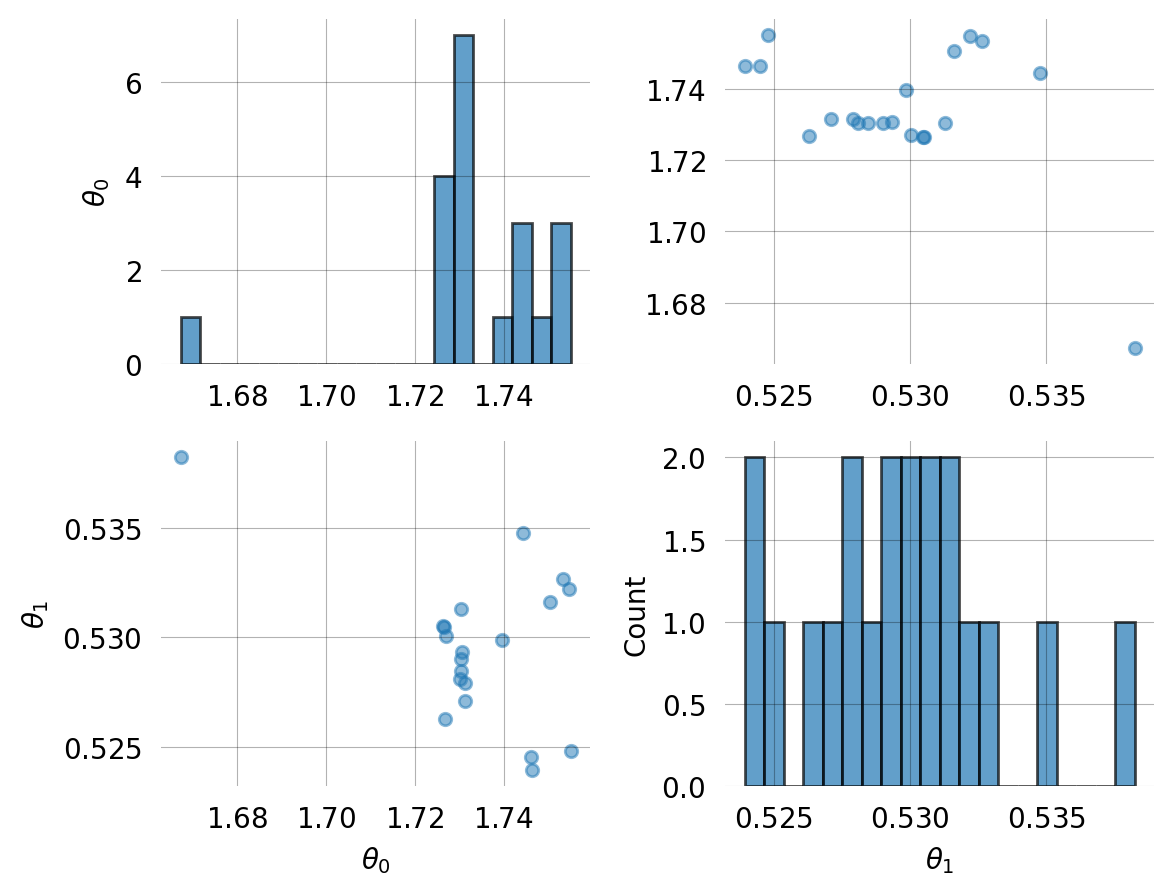

In [ ]:
#| label: fig-two-island-pairwise-hamadryas-anubis
#| fig-cap: 'Pairwise posterior for *P. kindae* × *P. cynocephalus*.'
#| fig-width: 5
#| fig-height: 3.5

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_pairwise()


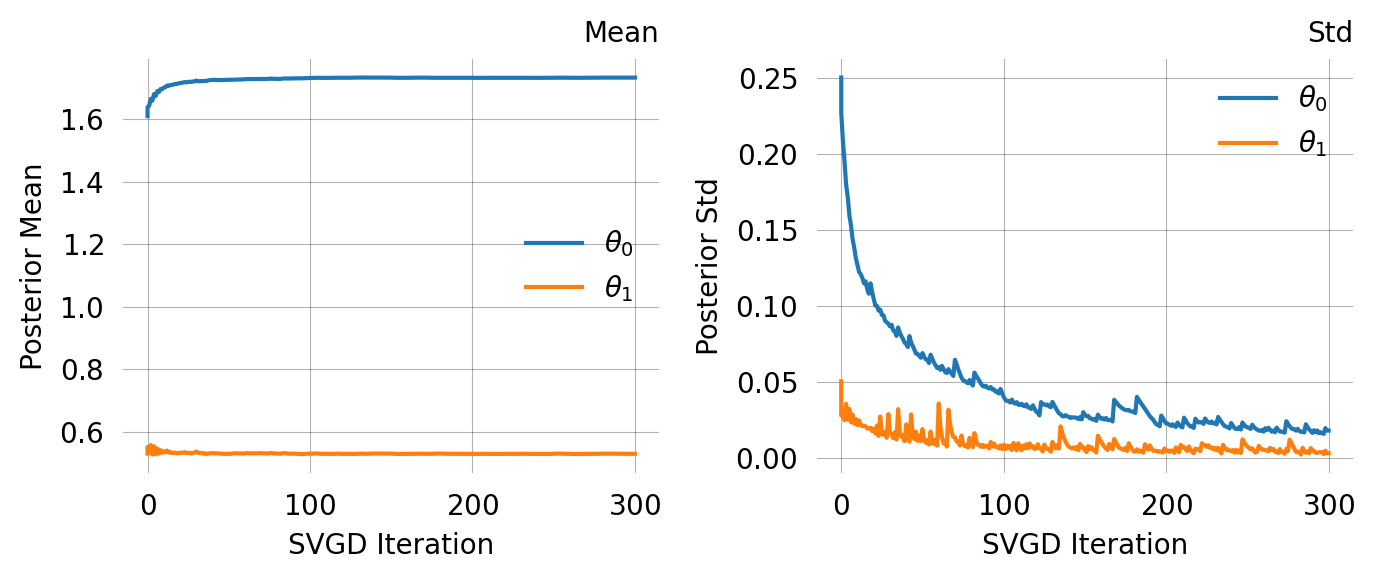

In [ ]:
#| label: fig-two-island-convergence-kindae-cynocephalus
#| fig-cap: 'Konvergensplot for to-ø modellen, *P. kindae* × *P. cynocephalus*. Venstre figur viser posterior mean og højre figur viser posterior std for $\theta_0$ (blå) og $\theta_1$ (orange) over 300 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

if f'P_kinade×P_cynocehaplus' in two_island_results:
    two_island_results[f'P_kindae×P_cynochepalus']['sv'].plot_convergence()


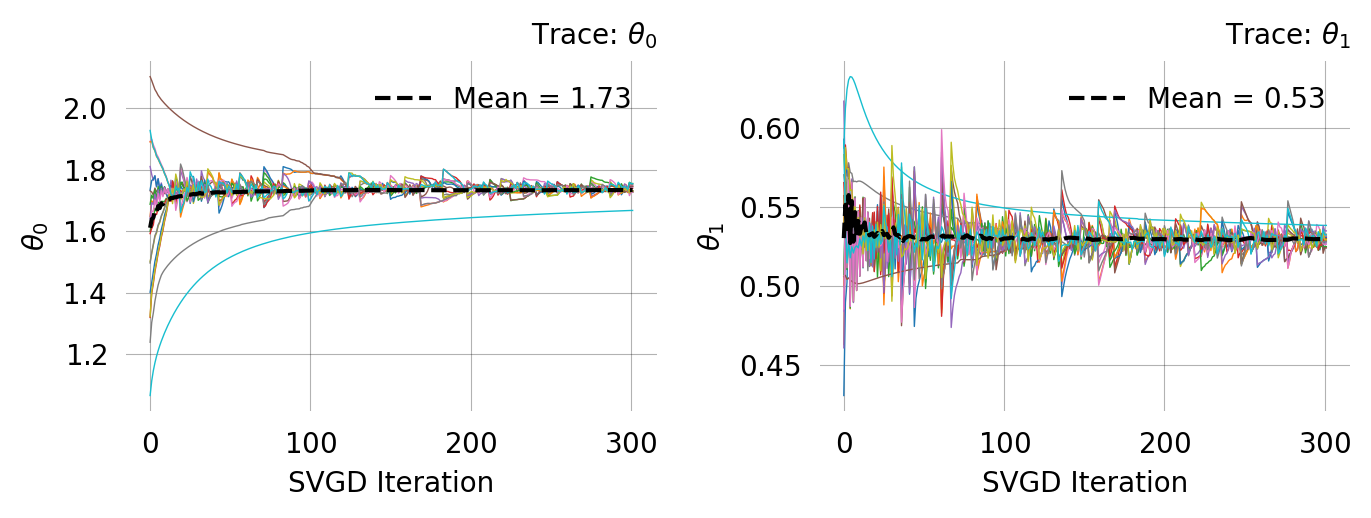

In [ ]:
#| label: fig-two-island-trace-kindae-cynocephalus
#| fig-cap: 'Trace plot for *P. kindae* × *P. cynocephalus*.'
#| fig-width: 5
#| fig-height: 3.5

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_trace()


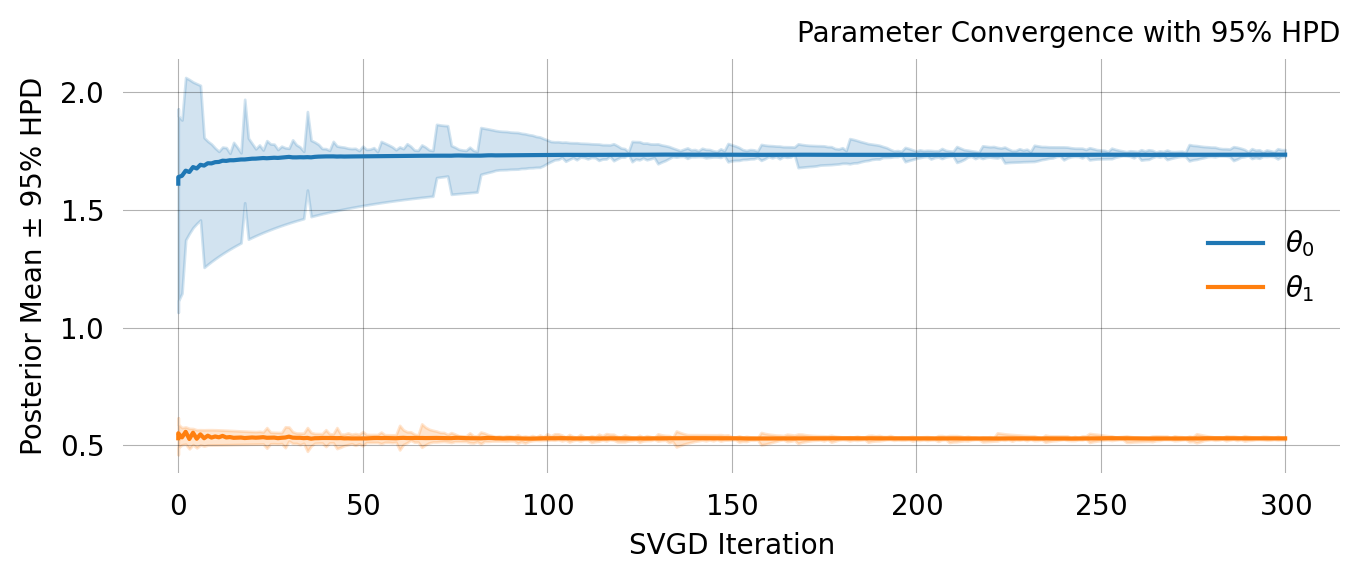

In [ ]:
#| label: fig-two-island-ci-kindae-cynocephalus
#| fig-cap: 'Posterior CI for to-ø modellen, *P. kindae* × *P. cynocephalus*. Den blå og orange kurve viser posterior mean for $\theta_0$ og $\theta_1$, og de skraverede områder viser de tilsvarende 95% HPD-intervaller over 300 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kinade×P_cynocephalus']['sv'].plot_ci()


## IM-modellen: Split-tidspunkt og ancestral $N_e$

In [ ]:
#| label: tbl-im-bavian
#| tbl-cap: 'IM-model SVGD-estimater via epoch_starts ($t_s=1{,}0$) for *P. cynocephalus* × *P. anubis*. $\hat{\theta}_0$: coalescentrate epoke 0 (moderne), $\hat{\theta}_1$: coalescentrate epoke 1 (ancestral). $t_s$ er konverteret til år via $g=11$ (Sørensen et al. 2023).'

from phasic import LogGaussPrior, StateIndexer, Property, Graph, with_ipv, ExpStepSize, clear_caches
from functools import partial
from itertools import combinations_with_replacement
all_pairs_im = partial(combinations_with_replacement, r=2)

clear_caches()

N_SUB_IM = 4
N_OBS_IM = 50000
t_s = 0.05
G   = 11

pop1_name, pop2_name = 'P_cynocephalus', 'P_anubis'
df1, df2 = populations[pop1_name], populations[pop2_name]
theta_W1, theta_W2 = watterson_theta(df1), watterson_theta(df2)
theta_W_mean = (theta_W1 + theta_W2) / 2
mu_scaled = MU / theta_W_mean

# Coalescent-graf 
indexer_im = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=N_SUB_IM)]
)

@with_ipv([N_SUB_IM] + [0]*(N_SUB_IM-1))
def coal_im(state, indexer=None):
    transitions = []
    for i, j in all_pairs_im(indexer_im.lineage):
        p1 = indexer_im.lineage.index_to_props(i)
        p2 = indexer_im.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer_im.lineage.props_to_index(
            descendants=p1.descendants + p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

g_im = Graph(coal_im, indexer=indexer_im)
jp_im = g_im.joint_prob_graph(
    indexer_im, reward_limit=2, mutation_rate=mu_scaled, discrete=False,
)
print(f"Joint-graf: {jp_im.vertices_length()} tilstande, {jp_im.param_length()} parametre")

jp_im.update_weights([theta_W_mean, mu_scaled])
jpt = jp_im.joint_prob_table()
allowed_obs = set(tuple(x) for x in jpt[jpt.columns[:-1]].to_numpy().tolist())

obs_im = []
np.random.seed(42)
combined_df = pd.concat([df1, df2], ignore_index=True)
for _, row in combined_df.sample(N_OBS_IM * 10, random_state=42).iterrows():
    k, n = int(row['derived_count']), int(row['nr_samples'])
    if n < N_SUB_IM: continue
    k_sub = np.random.hypergeometric(k, n - k, N_SUB_IM)
    if k_sub == 0 or k_sub == N_SUB_IM: continue
    obs = [0] * N_SUB_IM
    obs[k_sub - 1] = 1
    if tuple(obs) in allowed_obs:
        obs_im.append(obs)
    if len(obs_im) >= N_OBS_IM:
        break
print(f"Antal observationer: {len(obs_im)}")

# SVGD med epoch_starts
jp_im.update_weights([theta_W_mean, mu_scaled])

sv_im = jp_im.svgd(
    obs_im,
    preconditioner=None,
    fixed=[(1, mu_scaled)],
    prior=[
        LogGaussPrior(ci=[0.1, 10.0]),   
        None,                              
    ],
    learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
    epoch_starts=[0, t_s],
    n_iterations=300,
    n_particles=20,
)

res_im = sv_im.get_results()
print("theta_mean:", res_im['theta_mean'])
print("theta_std:", res_im['theta_std'])


m0 = float(res_im['theta_mean'][0])   
m1 = float(res_im['theta_mean'][2])    
s0 = float(res_im['theta_std'][0])
s1 = float(res_im['theta_std'][2])    

Ne_ref = theta_W_mean / (4 * MU)
t_s_yr = t_s * 2 * Ne_ref * G

df_im = pd.DataFrame([{
    'Artpar':       f"{pop1_name}×{pop2_name}",
    'θ̂₀ (mod.)':   round(m0, 5),
    'θ̂₀ std':      round(s0, 5),
    'θ̂₁ (anc.)':   round(m1, 5),
    'θ̂₁ std':      round(s1, 5),
    't_s (år)':     f"{t_s_yr:,.0f}",
}])
df_im

theta_mean: [2.75858191e+00 5.00087326e-08 1.65735547e+00 5.00087326e-08]
theta_std: [3.33539363 0.         2.343814   0.        ]


,Artpar,θ̂₀ (mod.),θ̂₀ std,θ̂₁ (anc.),θ̂₁ std,t_s (år)
0,P_cynocephalus×P_anubis,2.75858,3.33539,1.65736,2.34381,"10,998,079"


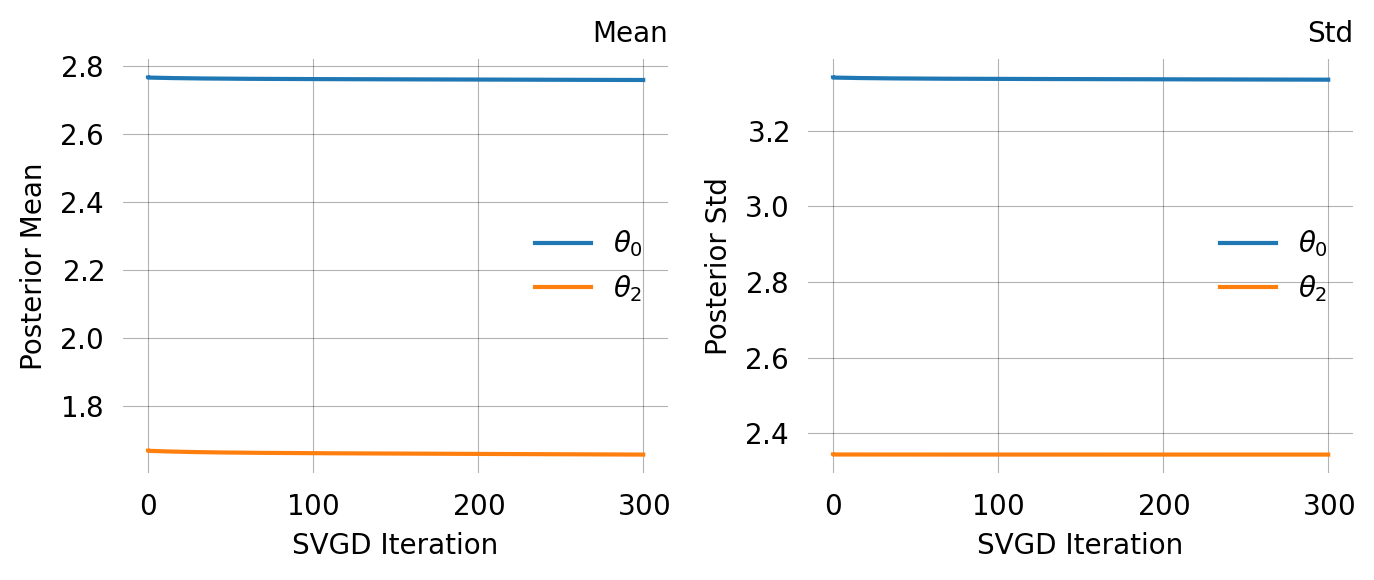

In [ ]:
#| label: fig-im-bavian-conv
#| fig-cap: 'Konvergensplot for IM-modellen via epoch_starts, *P. cynocephalus* × *P. anubis*. Venstre figur viser posterior mean og højre figur viser posterior std for $\theta_0$ (epoke 0, blå) og $\theta_2$ (epoke 1, orange) over 300 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_im.plot_convergence()

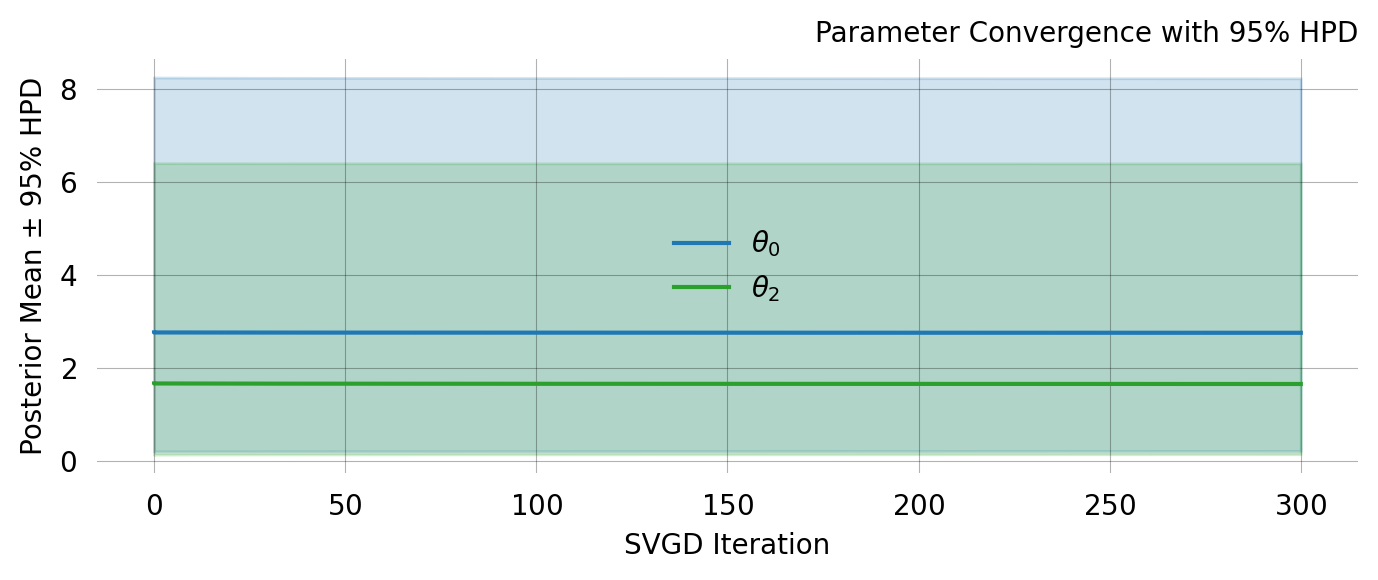

In [ ]:
#| label: fig-im-bavian-ci
#| fig-cap: 'Posterior CI for IM-modellen via epoch_starts, *P. cynocephalus* × *P. anubis*. Den blå og grønne kurve viser posterior mean for $\theta_0$ (epoke 0) og $\theta_2$ (epoke 1). De skraverede områder viser de tilsvarende 95% HPD-intervaller over 300 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_im.plot_ci(ci_method='hpd')

## To-locus ARG: Rekombinationsrate

In [7]:
DATA_DIR = Path('/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR')
OUT_DIR  = Path('output')
OUT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

In [ ]:
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) 
ac = variant_allele_counts["variant_allele_count"].values   
nr_samples = ac.sum(axis=1)  

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})

In [ ]:
population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744', 'PD_0204', 
                            'PD_0205', 'PD_0206', 'PD_0207',],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                                                           
}

In [10]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} prøver")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} prøver")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} prøver")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} prøver")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} prøver")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} prøver")

Yellow baboon: 60 prøver
Kinda baboon:  25 prøver
Olive baboon: 90 prøver
Guinea baboon: 12 prøver
Chacma baboon: 4 prøver
Hamadryas baboon: 24 prøver


In [11]:
def extract_pop(ds, ids):
    mask = np.isin(ds['sample_id'].values, ids)
    return ds.isel(samples=mask)

ds_pops = {name: extract_pop(ds, ids) for name, ids in population_map.items()}

pop_n = {name: ds_pops[name].sizes['samples'] * 2 for name in ds_pops}
for name, n in pop_n.items(): 
    print(f"{name:<22}: n={n} haplotyper ({n//2} individer)")
n_min = min(pop_n.values())
print(f"\nMindste population: n={n_min} (bruges til sammenligning)")

P_cynocephalus        : n=120 haplotyper (60 individer)
P_kindae              : n=50 haplotyper (25 individer)
P_anubis              : n=180 haplotyper (90 individer)
P_papio               : n=24 haplotyper (12 individer)
P_ursinus             : n=8 haplotyper (4 individer)
P_hamadryas           : n=48 haplotyper (24 individer)

Mindste population: n=8 (bruges til sammenligning)


In [ ]:
#| label: tbl-arg-bavian
#| tbl-cap: 'ARG-model SVGD-estimater for *P. cynocephalus*, kromosom 20. $\hat{\theta}_0$: coalescentrate, $\hat{\theta}_1$: rekombinationsrate (skaleret).'

from phasic import LogGaussPrior, GaussPrior, StateIndexer, Property, Graph, with_ipv, ExpStepSize, clear_caches
import sgkit as sg

clear_caches()

N_SUB_ARG = 3   

ds_pop = ds_pops['P_cynocephalus']
vac = sg.count_variant_alleles(ds_pop)
ac  = vac['variant_allele_count'].values   
gt  = ds_pop['call_genotype'].values        

positions = ds_pop['variant_position'].values
n_variants, n_samples, ploidy = gt.shape

hap = gt.reshape(n_variants, n_samples * ploidy)
n_hap = hap.shape[1]
print(f"n_variants={n_variants}, n_haplotypes={n_hap}")

derived_count = ac[:, 1]
seg_mask = (derived_count > 0) & (derived_count < n_hap)
positions_seg = positions[seg_mask]
hap_seg = hap[seg_mask]
print(f"Segregerende SNPs: {len(positions_seg)}")

def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i: lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo: lo += 1
        if hi <= i: hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi: hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
snp_pairs = pairs_in_range(positions_seg, min_dist, max_dist)
print(f"Antal SNP-par i afstandsvindue [{min_dist}, {max_dist}]: {len(snp_pairs)}")

snp_pairs = np.array(snp_pairs)
mask = np.ones(len(snp_pairs), dtype=bool)
if len(snp_pairs) > 1:
    mask[1:] = (snp_pairs[1:, 0] != snp_pairs[:-1, 0]) & (snp_pairs[1:, 1] != snp_pairs[:-1, 1])
snp_pairs = snp_pairs[mask]
print(f"Efter filtrering: {len(snp_pairs)} par")

rng = np.random.default_rng(42)
N_OBS_ARG = 1000

obs_arg = []
for i, j in snp_pairs[:N_OBS_ARG * 5]:
    sub_idx = rng.choice(n_hap, size=N_SUB_ARG, replace=False)
    g1 = hap_seg[i, sub_idx]
    g2 = hap_seg[j, sub_idx]

    loc1_count = int(g1.sum())
    loc2_count = int(g2.sum())

    if loc1_count == 0 or loc1_count == N_SUB_ARG: continue
    if loc2_count == 0 or loc2_count == N_SUB_ARG: continue

    # one-hot encode: loc1_0..loc1_N, loc2_0..loc2_N
    obs = [0] * (N_SUB_ARG + 1) + [0] * (N_SUB_ARG + 1)
    obs[loc1_count] = 1
    obs[(N_SUB_ARG + 1) + loc2_count] = 1
    obs_arg.append(obs)

    if len(obs_arg) >= N_OBS_ARG:
        break

print(f"Antal observationer: {len(obs_arg)}")

indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=N_SUB_ARG),
        Property('loc2', min_value=0, max_value=N_SUB_ARG),
    ]
)
initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = N_SUB_ARG

@with_ipv(initial_arg)
def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer_arg.state_length):
        if state[i] == 0: continue
        pi = indexer_arg.descendants.index_to_props(i)

        for j in range(i, indexer_arg.state_length):
            if state[j] == 0: continue
            pj = indexer_arg.descendants.index_to_props(j)

            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue

            child = state.copy()
            child[i] -= 1; child[j] -= 1
            des_loc1 = pi.loc1 + pj.loc1
            des_loc2 = pi.loc2 + pj.loc2
            if des_loc1 <= N_SUB_ARG and des_loc2 <= N_SUB_ARG:
                child[indexer_arg.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0 and pi.loc1 > 0 and pi.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer_arg.descendants.props_to_index(loc1=0, loc2=pi.loc2)] += 1
            child[indexer_arg.descendants.props_to_index(loc1=pi.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])

    return transitions

g_arg = Graph(two_locus_arg, indexer=indexer_arg)
print(f"ARG-graf: {g_arg.vertices_length()} tilstande")

theta_W_cyno = watterson_theta(populations['P_cynocephalus'])
mu_arg = MU / theta_W_cyno

jp_arg = g_arg.joint_prob_graph(
    indexer_arg,
    reward_only=['loc1', 'loc2'],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mu_arg,
)
print(f"Joint-graf: {jp_arg.vertices_length()} tilstande, {jp_arg.param_length()} parametre")

# SVGD 
sv_arg = jp_arg.svgd(
    observed_data=obs_arg,
    fixed=[(2, mu_arg)],
    n_iterations=100,
    n_particles=200,
    prior=[
        LogGaussPrior(ci=[theta_W_cyno * 0.05, theta_W_cyno * 20]),
        LogGaussPrior(ci=[0.01, 10]),
        None,
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
)
sv_arg.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             0.1552     0.5887     1.397      0.01075      2.221       
1          No             0.2317     1.652      6.237      0.0003514    7.101       
2          Yes            4.824e-08  NA         NA         NA           NA          

Particles: 200, Iterations: 100


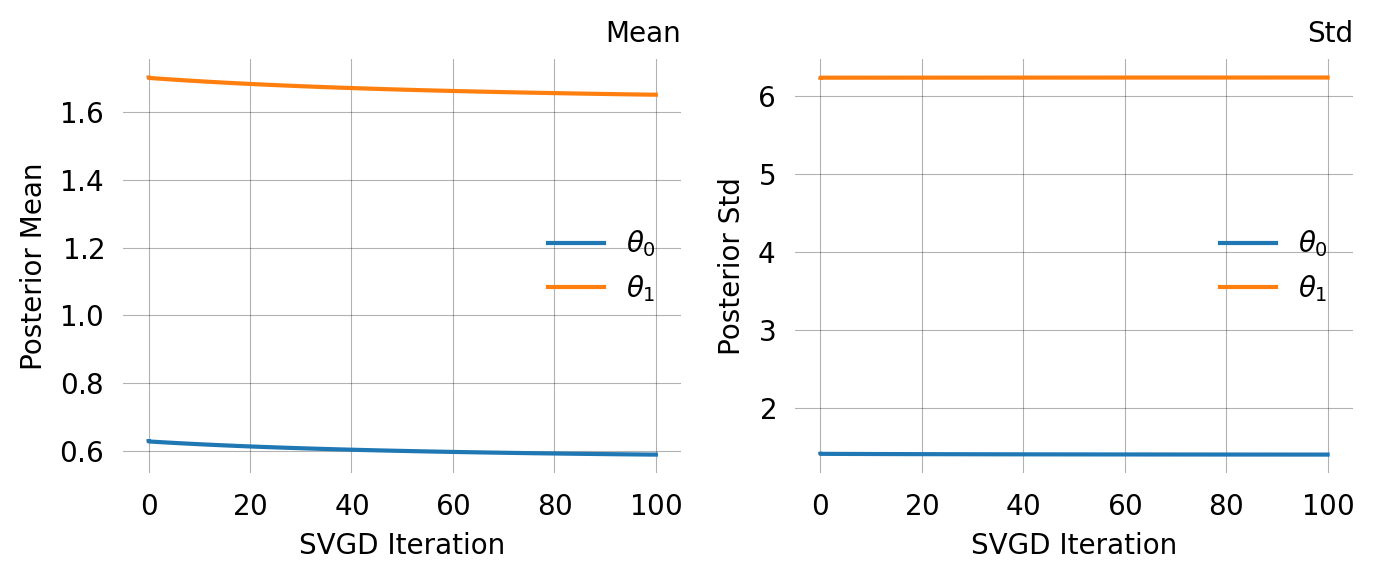

In [ ]:
#| label: fig-arg-bavian-conv
#| fig-cap: 'Konvergensplot for ARG-modellen, *P. cynocephalus*. Venstre figur viser posterior mean og højre figur viser posterior std for $\theta_0$ ($\hat\theta$, blå) og $\theta_1$ ($\hat\rho$, orange) over 100 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_convergence()

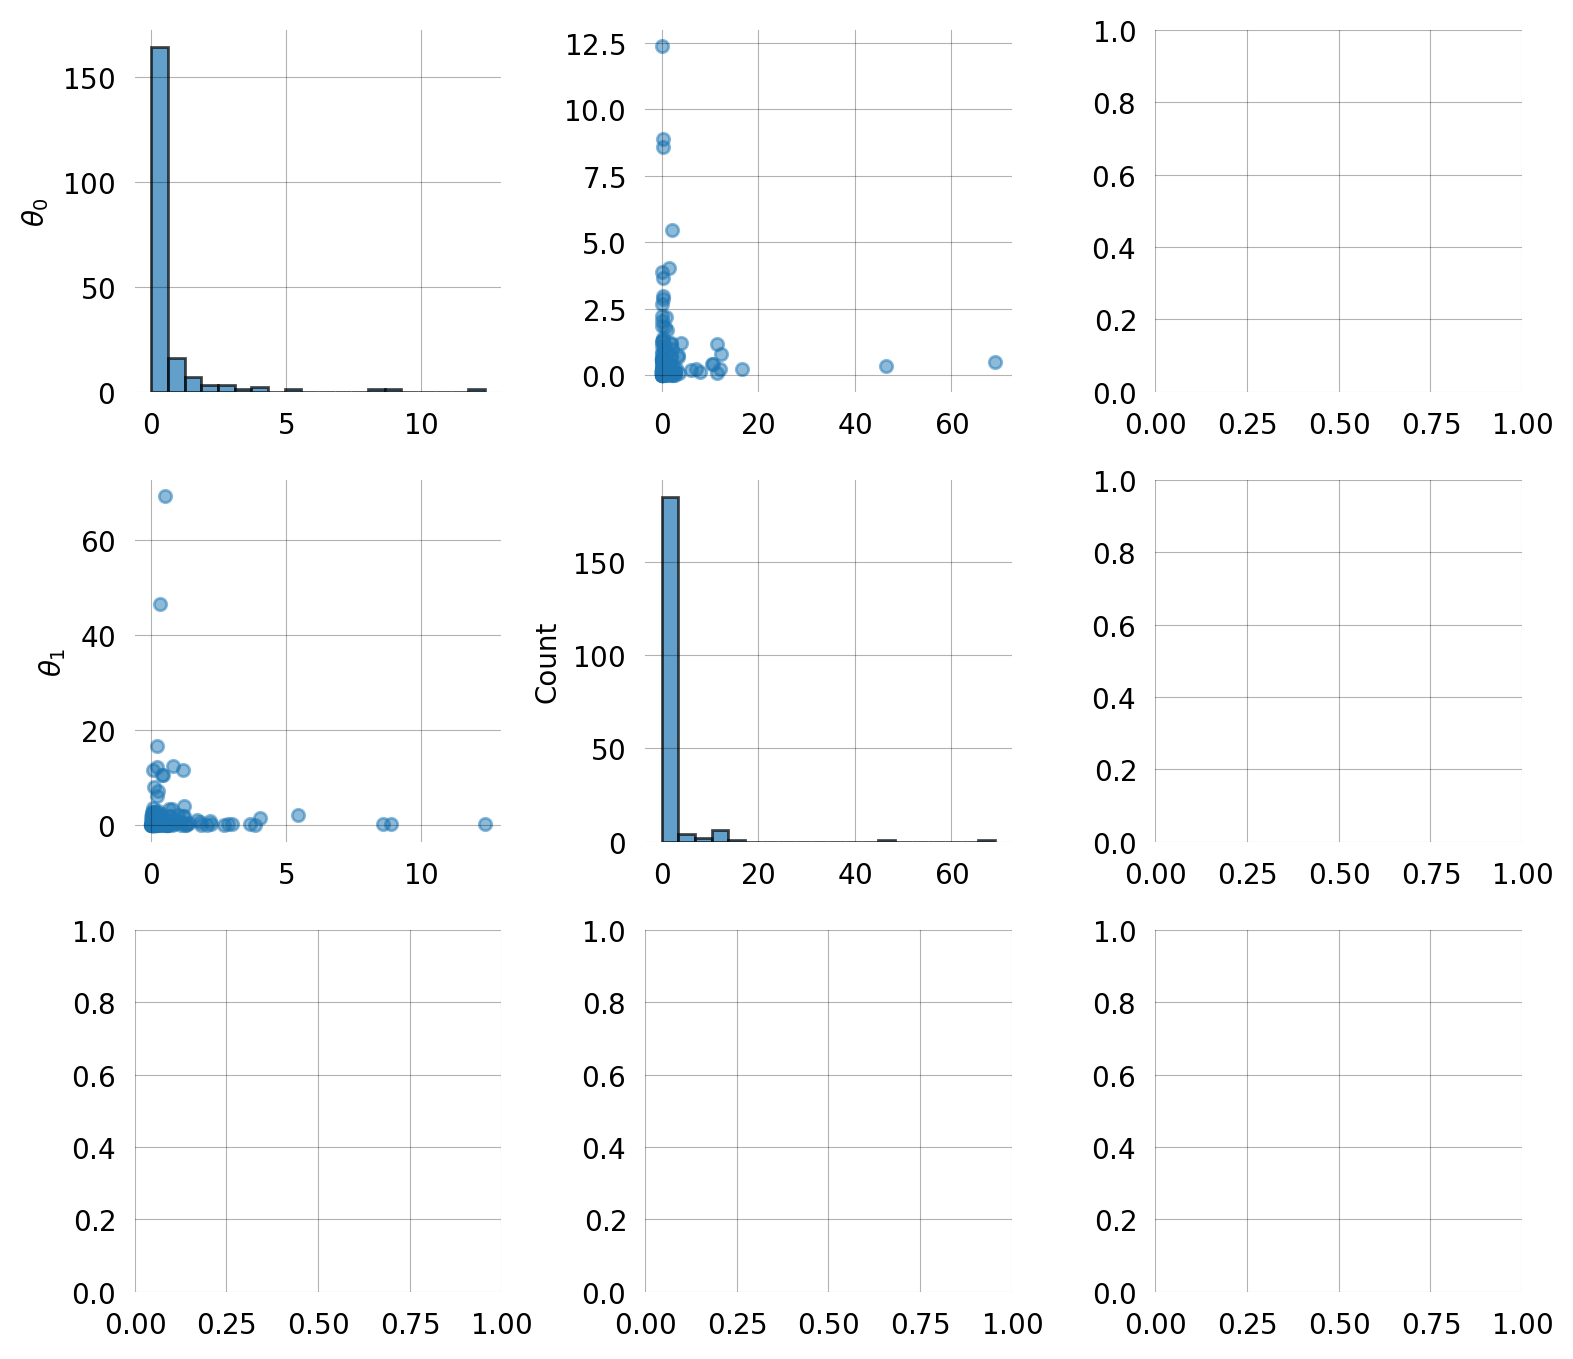

In [ ]:
#| label: fig-arg-bavian-pairwise
#| fig-cap: 'Posterior CI for ARG-modellen ($\theta$ vs. $\rho$), *P. cynocephalus*. Den blå og orange kurve viser posterior mean for $\hat\theta$ og $\hat\rho$, og de skraverede områder viser de tilsvarende 95% HPD-intervaller over 100 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_pairwise()

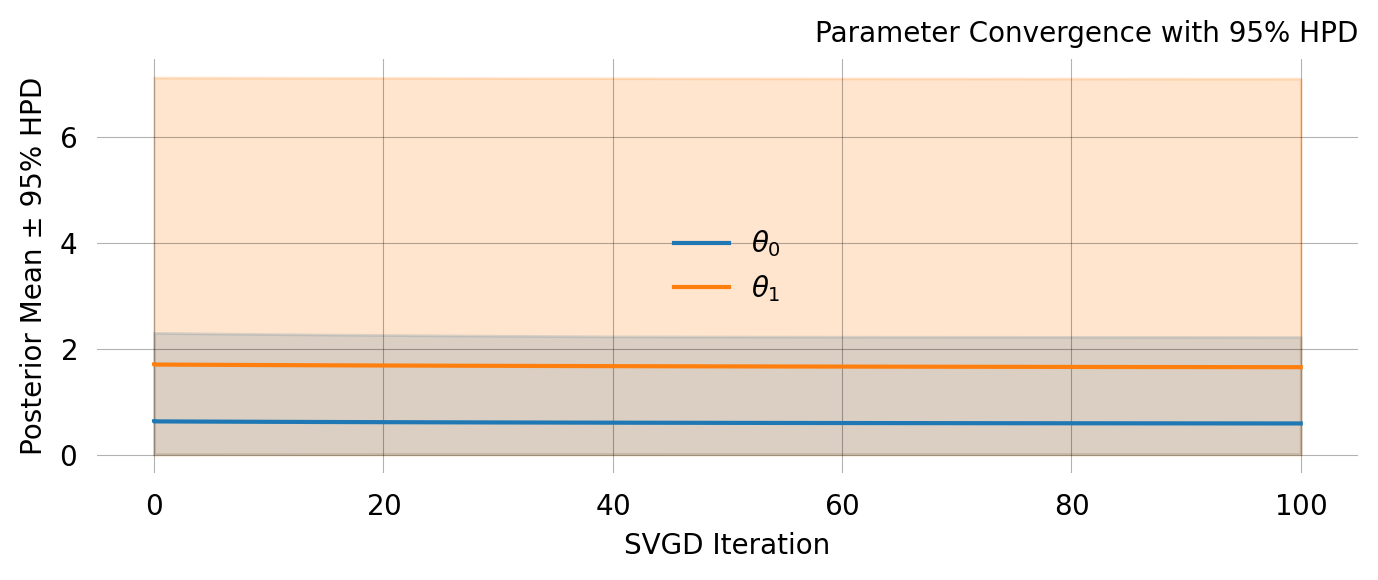

In [ ]:
#| label: fig-arg-bavian-ci
#| fig-cap: 'Posterior CI for ARG-modellen ($\theta$ vs. $\rho$), *P. cynocephalus*. Den blå og orange kurve viser posterior mean for $\hat\theta$ og $\hat\rho$, og de skraverede områder viser de tilsvarende 95% HPD-intervaller over 100 SVGD-iterationer.'
#| fig-width: 5
#| fig-height: 3.5

sv_arg.plot_ci()